# <b><div style='padding:8px;background-color:#003f88;color:white;border-radius:2px;font-size:100%;text-align: left'>Trial Activation</div></b>

## **Taks 3: Descriptive Analytics & Product Metrics**

## **Overview**

With the data cleaned in Task 1 and the SQL models built in Task 2,
Task 3 shifts focus to answering the product team's core questions:
Who is converting? When? Which parts of the platform are being used?
And where are organisations dropping off before they ever activate?

Using the cleaned dataset (stg_events_clean.csv) — the same source
that powers the SQL mart models — we compute nine product metrics,
produce three dashboard visualisations, and close with actionable
recommendations for the product and onboarding teams.

In [1]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {
    'converted':     '#2ecc71',
    'not_converted': '#e74c3c',
    'neutral':       '#3498db',
    'highlight':     '#f39c12',
    'purple':        '#9b59b6',
    'dark':          '#2c3e50',
}

In [2]:
# Load the event-level cleaned data (for daily/weekly metrics)
df = pd.read_csv(r"C:\Users\Harrison\Desktop\trial_activation\outputs\stg_events_clean.csv")

# Cast datetime columns 
for col in ['TIMESTAMP', 'TRIAL_START', 'TRIAL_END', 'CONVERTED_AT']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df['trial_day_int'] = df['days_into_trial'].clip(lower=0).astype(int)

# Load the org-level feature matrix (already has goal flags from Task 1) 
org_df = pd.read_csv(r"C:\Users\Harrison\Desktop\trial_activation\outputs\stg_org_features.csv")

# Cast datetime columns 
for col in ['trial_start', 'trial_end', 'converted_at',
            'first_event_ts', 'last_event_ts']:
    org_df[col] = pd.to_datetime(org_df[col], errors='coerce')

print(f"Events loaded    : {len(df):,}")
print(f"Orgs loaded      : {len(org_df):,}")
print(f"Columns in org_df: {list(org_df.columns)}")

Events loaded    : 102,895
Orgs loaded      : 966
Columns in org_df: ['ORGANIZATION_ID', 'converted', 'trial_start', 'trial_end', 'converted_at', 'total_events', 'unique_acts', 'first_event_ts', 'last_event_ts', 'days_to_convert', 'trial_active_days', 'Absence.Request.Approved', 'Absence.Request.Created', 'Absence.Request.Rejected', 'Break.Activate.Finished', 'Break.Activate.Started', 'Communication.Message.Created', 'Integration.Xero.PayrollExport.Synced', 'Mobile.Schedule.Loaded', 'PunchClock.Entry.Edited', 'PunchClock.PunchedIn', 'PunchClock.PunchedOut', 'PunchClockEndNote.Add.Completed', 'PunchClockStartNote.Add.Completed', 'Revenue.Budgets.Created', 'Scheduling.Availability.Set', 'Scheduling.OpenShiftRequest.Approved', 'Scheduling.OpenShiftRequest.Created', 'Scheduling.Shift.Approved', 'Scheduling.Shift.AssignmentChanged', 'Scheduling.Shift.Created', 'Scheduling.ShiftHandover.Accepted', 'Scheduling.ShiftHandover.Created', 'Scheduling.ShiftSwap.Accepted', 'Scheduling.ShiftSwap.Crea

In [3]:
# SETUP: All shared variables, constants and derived fields
# This cell must be run before any metric
# It defines every variable referenced throughout the notebook

# ── Goal definitions ──────────────────────────────────────────────────────
GOAL_DEFS = {
    'goal_1_core_scheduling':     ('Scheduling.Shift.Created',      3),
    'goal_2_schedule_visibility': ('Mobile.Schedule.Loaded',        3),
    'goal_3_time_tracking':       ('PunchClock.PunchedIn',          1),
    'goal_4_payroll_approval':    ('Scheduling.Shift.Approved',     1),
    'goal_5_team_comms':          ('Communication.Message.Created', 1),
}
GOAL_COLS = list(GOAL_DEFS.keys())

# ── Column groupings ──────────────────────────────────────────────────────
META_COLS = [
    'ORGANIZATION_ID', 'converted', 'trial_start', 'trial_end',
    'converted_at', 'total_events', 'unique_acts', 'days_to_convert',
    'trial_active_days', 'first_event_ts', 'last_event_ts',
    'trial_activated', 'goals_completed_n', 'engagement_tier'
]
ACTIVITY_COLS = [c for c in org_df.columns if c not in META_COLS
                 and not c.startswith('goal_')]

# ── Module map ────────────────────────────────────────────────────────────
MODULE_MAP = {
    'Scheduling':      [c for c in ACTIVITY_COLS if 'Scheduling' in c
                        or c in ('Mobile.Schedule.Loaded',
                                 'Shift.View.Opened',
                                 'ShiftDetails.View.Opened')],
    'Time&Attendance': [c for c in ACTIVITY_COLS if 'Punch' in c
                        or 'Break' in c],
    'Absence Mgmt':    [c for c in ACTIVITY_COLS if 'Absence' in c],
    'Payroll&Finance': [c for c in ACTIVITY_COLS if any(
                        k in c for k in ('Xero', 'Budgets', 'Timesheets'))],
    'Communication':   [c for c in ACTIVITY_COLS if 'Communication' in c],
}

# ── Recompute derived columns not saved in the CSV ────────────────────────
org_df['goals_completed_n'] = org_df[GOAL_COLS].sum(axis=1)

org_df['first_bottleneck'] = org_df.apply(
    lambda row: next(
        (g.replace('goal_', '').replace('_', ' ').title()
         for g in GOAL_COLS if not row[g]),
        'Fully Activated'
    ), axis=1
)

# ── Core metric variables ─────────────────────────────────────────────────
n_total    = len(org_df)
n_conv     = org_df['converted'].sum()
n_activ    = org_df['trial_activated'].sum()
conv_rate  = n_conv / n_total
activ_rate = n_activ / n_total

conv_if_activated  = org_df.loc[ org_df['trial_activated'], 'converted'].mean()
conv_if_not_activ  = org_df.loc[~org_df['trial_activated'], 'converted'].mean()

# ── Time-to-convert ───────────────────────────────────────────────────────
d2c = org_df.loc[
    org_df['converted'] & org_df['days_to_convert'].notna(),
    'days_to_convert'
]

# ── Daily event volume ────────────────────────────────────────────────────
df['trial_day_int'] = df['days_into_trial'].clip(lower=0).astype(int)

daily = (
    df[df['trial_day_int'].between(0, 30)]
    .groupby(['CONVERTED', 'trial_day_int'])
    .size()
    .reset_index(name='event_count')
)
daily['events_per_org'] = daily.apply(
    lambda r: r['event_count'] / (n_conv if r['CONVERTED'] else (n_total - n_conv)),
    axis=1
)

# ── Sequential activation funnel ──────────────────────────────────────────
funnel_stages = [
    ('Signed up for trial',                n_total),
    ('G1 — Core Scheduling (≥3 shifts)',   org_df['goal_1_core_scheduling'].sum()),
    ('G2 — Schedule Viewed (≥3 times)',
        (org_df['goal_1_core_scheduling'] &
         org_df['goal_2_schedule_visibility']).sum()),
    ('G3 — Time Tracking (≥1 punch-in)',
        org_df[['goal_1_core_scheduling',
                'goal_2_schedule_visibility',
                'goal_3_time_tracking']].all(axis=1).sum()),
    ('G4 — Payroll Approval (≥1 approval)',
        org_df[['goal_1_core_scheduling',
                'goal_2_schedule_visibility',
                'goal_3_time_tracking',
                'goal_4_payroll_approval']].all(axis=1).sum()),
    ('G5 — Team Comms (≥1 message)  [ACTIVATED]',
        org_df['trial_activated'].sum()),
]

# ── Module adoption summary ───────────────────────────────────────────────
mod_rows = []
for mod, cols in MODULE_MAP.items():
    if not cols:
        continue
    used       = (org_df[cols] > 0).any(axis=1)
    adoption   = used.mean()
    conv_used  = org_df.loc[used,  'converted'].mean() if used.sum() > 0 else 0
    conv_nused = org_df.loc[~used, 'converted'].mean() if (~used).sum() > 0 else 0
    lift       = conv_used / max(conv_nused, 0.001)
    mod_rows.append({
        'module':    mod,
        'adoption':  adoption,
        'conv_used': conv_used,
        'conv_nused':conv_nused,
        'lift':      lift
    })
mod_df = pd.DataFrame(mod_rows)

# ── Feature engagement depth ──────────────────────────────────────────────
depth_rows = []
for act in ACTIVITY_COLS:
    users = org_df[org_df[act] > 0]
    if len(users) < 5:
        continue
    depth_rows.append({
        'activity':      act,
        'n_orgs_using':  len(users),
        'median_events': users[act].median(),
        'mean_events':   users[act].mean(),
        'p90_events':    users[act].quantile(0.9),
    })
depth_df = pd.DataFrame(depth_rows).sort_values('median_events', ascending=False)

# ── Cohort breakdown ──────────────────────────────────────────────────────
org_df['trial_start_month'] = pd.to_datetime(
    org_df['trial_start']).dt.to_period('M')
cohort = org_df.groupby('trial_start_month').agg(
    n_orgs    = ('ORGANIZATION_ID', 'count'),
    n_conv    = ('converted',       'sum'),
    conv_rate = ('converted',       'mean'),
).reset_index()
cohort['trial_start_month'] = cohort['trial_start_month'].astype(str)

# ── Confirm all variables are ready ──────────────────────────────────────
print("All variables defined.")
print(f"  n_total         : {n_total:,}")
print(f"  n_conv          : {int(n_conv):,}")
print(f"  n_activ         : {int(n_activ):,}")
print(f"  conv_rate       : {conv_rate:.2%}")
print(f"  activ_rate      : {activ_rate:.2%}")
print(f"  d2c median      : {d2c.median():.0f} days")
print(f"  funnel stages   : {len(funnel_stages)}")
print(f"  mod_df rows     : {len(mod_df)}")
print(f"  depth_df rows   : {len(depth_df)}")
print(f"  daily rows      : {len(daily)}")
print(f"  cohort rows     : {len(cohort)}")

All variables defined.
  n_total         : 966
  n_conv          : 206
  n_activ         : 65
  conv_rate       : 21.33%
  activ_rate      : 6.73%
  d2c median      : 30 days
  funnel stages   : 6
  mod_df rows     : 5
  depth_df rows   : 25
  daily rows      : 60
  cohort rows     : 3


## **Metric 1 — Overall Conversion Rate**

The conversion rate is the foundational metric of the entire challenge.
It tells us what proportion of trialling organisations ultimately became
paying customers. We compute this at the overall level and break it down
by monthly cohort (January, February, March) to detect whether conversion
performance is improving, declining, or stable across intake periods.
This metric establishes the 21.3% baseline that every other metric and
goal is benchmarked against.

In [4]:
# Overall Conversion Rate*

print(f"\n  Total trial organisations : {n_total:,}")
print(f"  Converted to paid         : {n_conv:,}")
print(f"  Did NOT convert           : {n_total - n_conv:,}")
print(f"  ── Conversion Rate        : {conv_rate:.2%}")

# Cohort breakdown by trial start month
org_df['trial_start_month'] = org_df['trial_start'].dt.to_period('M')
cohort = org_df.groupby('trial_start_month').agg(
    n_orgs    = ('ORGANIZATION_ID', 'count'),
    n_conv    = ('converted', 'sum'),
    conv_rate = ('converted', 'mean'),
).reset_index()
cohort['trial_start_month'] = cohort['trial_start_month'].astype(str)

print("\n  Monthly Cohort Breakdown:")
print(f"  {'Month':<12} {'Orgs':>6}  {'Converted':>10}  {'Conv Rate':>10}")
print("  " + "-" * 44)
for _, row in cohort.iterrows():
    print(f"  {row['trial_start_month']:<12} {row['n_orgs']:>6}  "
          f"{row['n_conv']:>10}  {row['conv_rate']:>9.1%}")


  Total trial organisations : 966
  Converted to paid         : 206
  Did NOT convert           : 760
  ── Conversion Rate        : 21.33%

  Monthly Cohort Breakdown:
  Month          Orgs   Converted   Conv Rate
  --------------------------------------------
  2024-01         305          70      23.0%
  2024-02         347          79      22.8%
  2024-03         314          57      18.2%


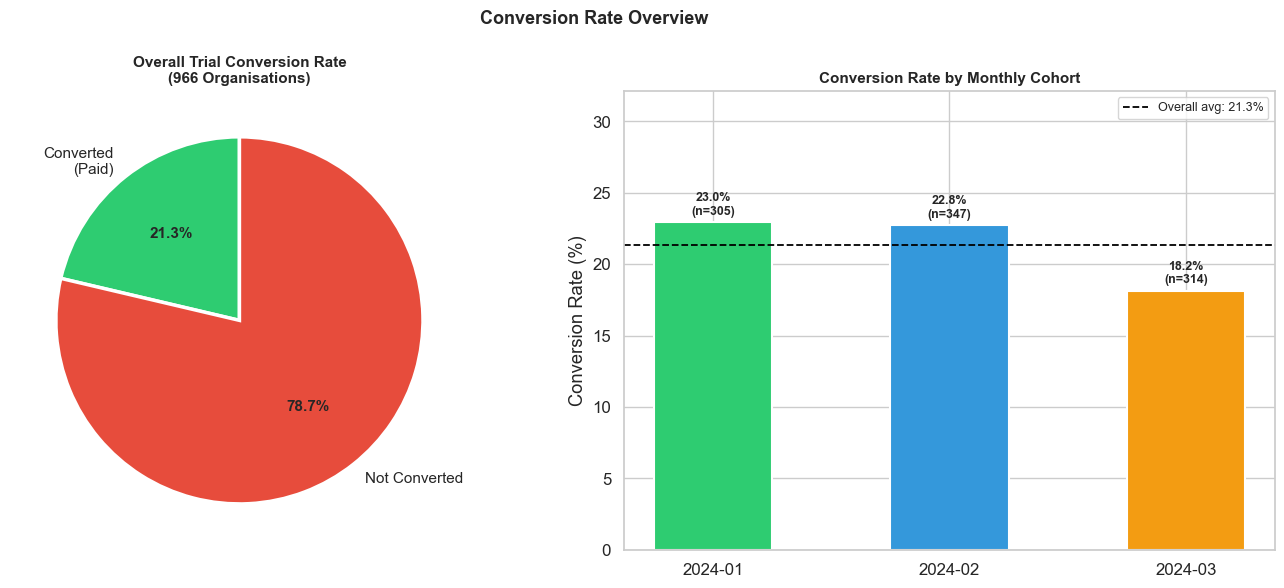

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Conversion Rate Overview', fontweight='bold', fontsize=13)

# Pie — overall conversion
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [n_conv, n_total - n_conv],
    labels=['Converted\n(Paid)', 'Not Converted'],
    colors=[COLORS['converted'], COLORS['not_converted']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Overall Trial Conversion Rate\n(966 Organisations)',
             fontweight='bold', fontsize=11)

# Bar — monthly cohort conversion
ax = axes[1]
bars = ax.bar(cohort['trial_start_month'], cohort['conv_rate'] * 100,
              color=[COLORS['converted'], COLORS['neutral'], COLORS['highlight']],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, (_, row) in zip(bars, cohort.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['conv_rate']:.1%}\n(n={row['n_orgs']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(conv_rate * 100, color='black', linestyle='--', linewidth=1.3,
           label=f'Overall avg: {conv_rate:.1%}')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Monthly Cohort',
             fontweight='bold', fontsize=11)
ax.set_ylim(0, max(cohort['conv_rate'].max() * 140, 30))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


>**Overall Trial Conversion Rate (Pie Chart)**
Shows the proportion of the 966 trialling organisations that converted
to a paying customer (21.3%) versus those that did not (78.7%). This
establishes the baseline conversion rate that every subsequent metric
and goal is benchmarked against throughout the analysis.

>**Conversion Rate by Monthly Cohort (Bar Chart)**
Breaks the overall conversion rate down by the month organisations
started their trial — January (23.0%), February (22.8%), and March
(18.2%). This reveals whether the platform's ability to convert
trialists is consistent across intake periods or whether specific
cohorts are underperforming, which could indicate seasonal effects
or changes in the quality of incoming trialists.

## **Metric 2 — Trial Activation Rate**

The trial activation rate measures the proportion of organisations that
completed all 5 trial goals defined in Task 1 — representing genuine,
end-to-end engagement with the platform's core value. We report the
overall activation rate and compare the conversion rate of activated
organisations against non-activated ones to assess whether completing
all goals is associated with a higher likelihood of converting. We also
report each goal's individual completion rate to show how many
organisations reached each milestone independently.

In [6]:
# Trial activation rate

activ_rate = n_activ / n_total
conv_if_activated   = org_df.loc[org_df['trial_activated'], 'converted'].mean()
conv_if_not_activ   = org_df.loc[~org_df['trial_activated'], 'converted'].mean()

print(f"\n  Orgs that completed ALL 5 goals  : {n_activ:,} ({activ_rate:.1%})")
print(f"  Conversion rate — ACTIVATED      : {conv_if_activated:.2%}")
print(f"  Conversion rate — NOT ACTIVATED  : {conv_if_not_activ:.2%}")
print(f"\n  Goal-by-Goal Completion Rates:")
print(f"  {'Goal':<40} {'N':>5}  {'Rate':>7}")
print("  " + "-" * 55)
for g, (col, thresh) in GOAL_DEFS.items():
    n_g = org_df[g].sum()
    lbl = g.replace('goal_', 'G').replace('_', ' ').title()
    print(f"  {lbl:<40} {n_g:>5}  {n_g/n_total:>6.1%}")

# Goals completed distribution
print(f"\n  Goals Completed Distribution:")
gcd = org_df['goals_completed_n'].value_counts().sort_index()
for k, v in gcd.items():
    bar = '█' * int(v / n_total * 50)
    print(f"  {k} goals: {v:>4} orgs ({v/n_total:5.1%})  {bar}")


  Orgs that completed ALL 5 goals  : 65 (6.7%)
  Conversion rate — ACTIVATED      : 16.92%
  Conversion rate — NOT ACTIVATED  : 21.64%

  Goal-by-Goal Completion Rates:
  Goal                                         N     Rate
  -------------------------------------------------------
  G1 Core Scheduling                         563   58.3%
  G2 Schedule Visibility                     348   36.0%
  G3 Time Tracking                           211   21.8%
  G4 Payroll Approval                        200   20.7%
  G5 Team Comms                              145   15.0%

  Goals Completed Distribution:
  0 goals:  268 orgs (27.7%)  █████████████
  1 goals:  341 orgs (35.3%)  █████████████████
  2 goals:  140 orgs (14.5%)  ███████
  3 goals:   87 orgs ( 9.0%)  ████
  4 goals:   65 orgs ( 6.7%)  ███
  5 goals:   65 orgs ( 6.7%)  ███


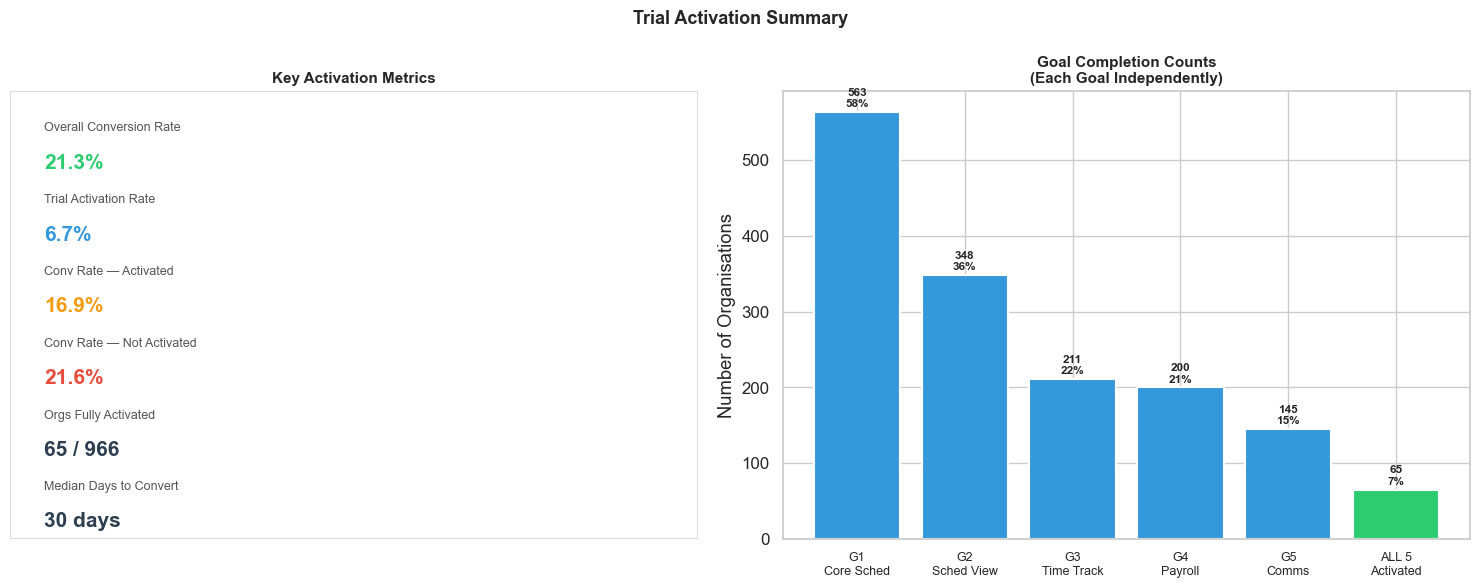

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Trial Activation Summary', fontweight='bold', fontsize=13)

# KPI text cards
ax = axes[0]
ax.axis('off')
kpi_text = [
    ("Overall Conversion Rate",   f"{conv_rate:.1%}",          COLORS['converted']),
    ("Trial Activation Rate",     f"{activ_rate:.1%}",         COLORS['neutral']),
    ("Conv Rate — Activated",     f"{conv_if_activated:.1%}",  COLORS['highlight']),
    ("Conv Rate — Not Activated", f"{conv_if_not_activ:.1%}",  COLORS['not_converted']),
    ("Orgs Fully Activated",      f"{int(n_activ)} / {n_total}",COLORS['dark']),
    ("Median Days to Convert",    f"{d2c.median():.0f} days",  COLORS['dark']),
]
for i, (label, value, color) in enumerate(kpi_text):
    y_pos = 0.93 - i * 0.16
    ax.text(0.05, y_pos,        label, transform=ax.transAxes,
            fontsize=9,  color='#555555', va='top')
    ax.text(0.05, y_pos - 0.07, value, transform=ax.transAxes,
            fontsize=15, fontweight='bold', color=color, va='top')
ax.set_title('Key Activation Metrics', fontweight='bold', fontsize=11)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
             edgecolor='#dddddd', linewidth=1.5, transform=ax.transAxes))

# Bar — each goal independently
ax = axes[1]
goal_labels_short = ['G1\nCore Sched', 'G2\nSched View',
                     'G3\nTime Track', 'G4\nPayroll',
                     'G5\nComms',      'ALL 5\nActivated']
goal_counts = [org_df[g].sum() for g in GOAL_COLS] + [n_activ]
bar_colors  = [COLORS['neutral']] * 5 + [COLORS['converted']]
bars = ax.bar(range(6), goal_counts, color=bar_colors,
              edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, goal_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{count}\n{count/n_total:.0%}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(range(6))
ax.set_xticklabels(goal_labels_short, fontsize=9)
ax.set_ylabel('Number of Organisations')
ax.set_title('Goal Completion Counts\n(Each Goal Independently)',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

>**Key Activation Metrics (KPI Cards)**
Provides an at-a-glance summary of the six most important headline
numbers from the analysis: overall conversion rate, trial activation
rate, conversion rate for activated vs non-activated organisations,
total organisations that fully activated, and median days to convert.
This serves as the executive summary of the entire trial activation
framework in a single view.

>**Goal Completion Counts — Each Goal Independently (Bar Chart)**
Shows how many organisations completed each of the 5 trial goals
independently — regardless of whether they completed the others.
The declining bar heights from Goal 1 (563 orgs, 58.3%) to Goal 5
(145 orgs, 15.0%) reveal a clear engagement gradient across the
platform's modules, showing which parts of the product are being
discovered and used during the trial and which are being missed.

## **Metric 3 — Module Adoption Rates**

The platform covers five distinct product modules: Scheduling,
Time & Attendance, Absence Management, Payroll & Finance, and
Communications. Module adoption measures what percentage of trialling
organisations used at least one activity within each module. We report
adoption rates alongside the conversion rate of organisations that used
each module vs those that did not, and compute a lift ratio to identify
which modules are associated with higher conversion outcomes. This helps
the product team understand which areas of the platform are being
discovered during the trial and which are being missed entirely.

In [8]:
# Module adoption rate

print(f"\n  {'Module':<22} {'Adoption':>9}  {'Conv (Used)':>12}  {'Conv (Not Used)':>16}  {'Lift':>6}")
print("  " + "-" * 70)
mod_rows = []
for mod, cols in MODULE_MAP.items():
    if not cols:
        continue
    used       = (org_df[cols] > 0).any(axis=1)
    adoption   = used.mean()
    conv_used  = org_df.loc[used,  'converted'].mean() if used.sum() > 0 else 0
    conv_nused = org_df.loc[~used, 'converted'].mean() if (~used).sum() > 0 else 0
    lift       = conv_used / max(conv_nused, 0.001)
    mod_rows.append({'module': mod, 'adoption': adoption,
                     'conv_used': conv_used, 'conv_nused': conv_nused, 'lift': lift})
    print(f"  {mod:<22} {adoption:>9.1%}  {conv_used:>12.1%}  {conv_nused:>16.1%}  {lift:>6.2f}x")

mod_df = pd.DataFrame(mod_rows)

# Individual activity adoption
print(f"\n  Individual Activity Adoption (% of orgs that used it):")
act_adopt = {a: (org_df[a] > 0).mean() for a in ACTIVITY_COLS}
adopt_df  = pd.Series(act_adopt).sort_values(ascending=False)
print(f"  {'Activity':<45} {'Adoption':>9}  {'N Orgs':>7}")
print("  " + "-" * 65)
for act, rate in adopt_df.items():
    n_a = (org_df[act] > 0).sum()
    print(f"  {act:<45} {rate:>9.1%}  {n_a:>7}")



  Module                  Adoption   Conv (Used)   Conv (Not Used)    Lift
  ----------------------------------------------------------------------
  Scheduling                 98.8%         21.6%              0.0%  215.93x
  Time&Attendance            21.8%         22.7%             20.9%    1.09x
  Absence Mgmt                4.1%         20.0%             21.4%    0.94x
  Payroll&Finance             1.7%          6.2%             21.6%    0.29x
  Communication              15.0%         16.6%             22.2%    0.75x

  Individual Activity Adoption (% of orgs that used it):
  Activity                                       Adoption   N Orgs
  -----------------------------------------------------------------
  Scheduling.Shift.Created                          87.8%      848
  Mobile.Schedule.Loaded                            47.2%      456
  Scheduling.Shift.AssignmentChanged                35.5%      343
  PunchClock.PunchedIn                              21.8%      211
  Scheduli

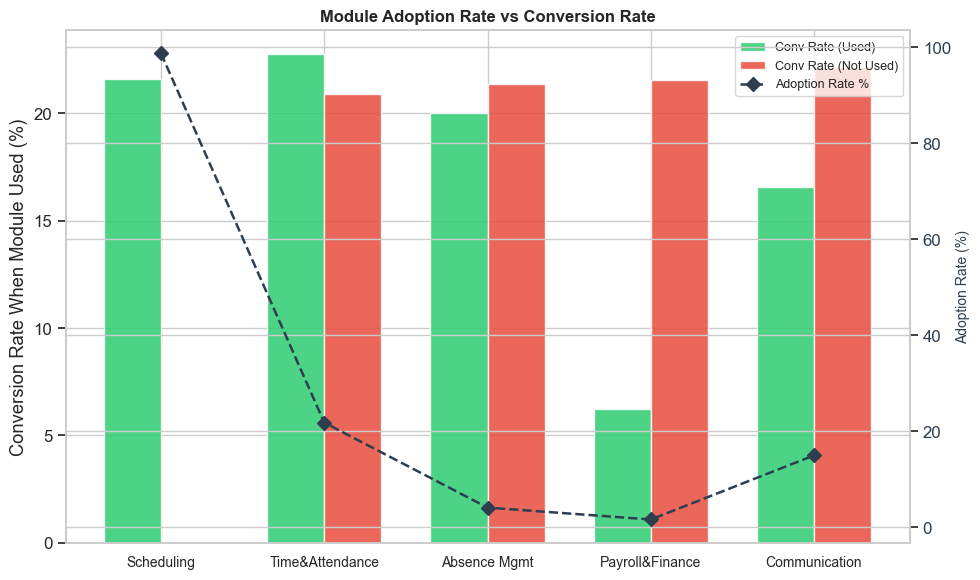

In [9]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(mod_df))
w = 0.35
ax.bar(x - w/2, mod_df['conv_used']  * 100, w, label='Conv Rate (Used)',
       color=COLORS['converted'],     alpha=0.85, edgecolor='white')
ax.bar(x + w/2, mod_df['conv_nused'] * 100, w, label='Conv Rate (Not Used)',
       color=COLORS['not_converted'], alpha=0.85, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(x, mod_df['adoption'] * 100, 'D--', color=COLORS['dark'],
         linewidth=1.8, markersize=7, label='Adoption Rate %')
ax2.set_ylabel('Adoption Rate (%)', color=COLORS['dark'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=COLORS['dark'])
ax.set_xticks(x)
ax.set_xticklabels(mod_df['module'], fontsize=10)
ax.set_ylabel('Conversion Rate When Module Used (%)')
ax.set_title('Module Adoption Rate vs Conversion Rate',
             fontweight='bold', fontsize=12)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()


>**Module Adoption Rate vs Conversion Rate visualization**
Shows the relationship between module adoption — the percentage of
organisations that used each product module at all — and the
conversion rate of organisations that used each module versus those
that did not. The secondary axis (diamond line) overlays the adoption
rate so both dimensions can be compared simultaneously. This chart
reveals whether widely adopted modules (like Scheduling at 98.8%)
actually drive better conversion outcomes, or whether less-adopted
modules like Time & Attendance (21.8%) are associated with meaningfully
different conversion rates — informing where onboarding investment
would have the greatest impact.

## **Metric 4 — Time-to-Convert**

Time-to-convert measures how many days elapsed between an organisation's
trial start date and the moment it converted to a paying customer. We
report the mean, median, standard deviation, and key percentiles (P25,
P75) for the 206 converted organisations, and compute cumulative
conversion milestones at Days 1, 3, 7, 14, 21, and 30. This metric
reveals the urgency pattern of conversion decisions — specifically
whether organisations convert early in the trial when they first
experience value, or delay until deadline pressure forces the decision.

In [10]:
# Time-To-Convert 

d2c = org_df.loc[
    org_df['converted'] & org_df['days_to_convert'].notna(),
    'days_to_convert'
]
print(f"\n  N (converted with timestamp) : {len(d2c):,}")
print(f"  Mean                         : {d2c.mean():.1f} days")
print(f"  Median                       : {d2c.median():.1f} days")
print(f"  Std Dev                      : {d2c.std():.1f} days")
print(f"  Min / Max                    : {d2c.min():.0f} / {d2c.max():.0f} days")
print(f"  P25 / P75                    : {d2c.quantile(0.25):.0f} / {d2c.quantile(0.75):.0f} days")
print(f"\n  Cumulative conversion milestones:")
for day in [1, 3, 7, 14, 21, 30]:
    n_by = (d2c <= day).sum()
    print(f"    Within {day:>2} days : {n_by:>4} ({n_by/len(d2c):.1%} of converters)")


  N (converted with timestamp) : 206
  Mean                         : 30.3 days
  Median                       : 30.0 days
  Std Dev                      : 8.2 days
  Min / Max                    : 14 / 64 days
  P25 / P75                    : 25 / 36 days

  Cumulative conversion milestones:
    Within  1 days :    0 (0.0% of converters)
    Within  3 days :    0 (0.0% of converters)
    Within  7 days :    0 (0.0% of converters)
    Within 14 days :    3 (1.5% of converters)
    Within 21 days :   31 (15.0% of converters)
    Within 30 days :  105 (51.0% of converters)


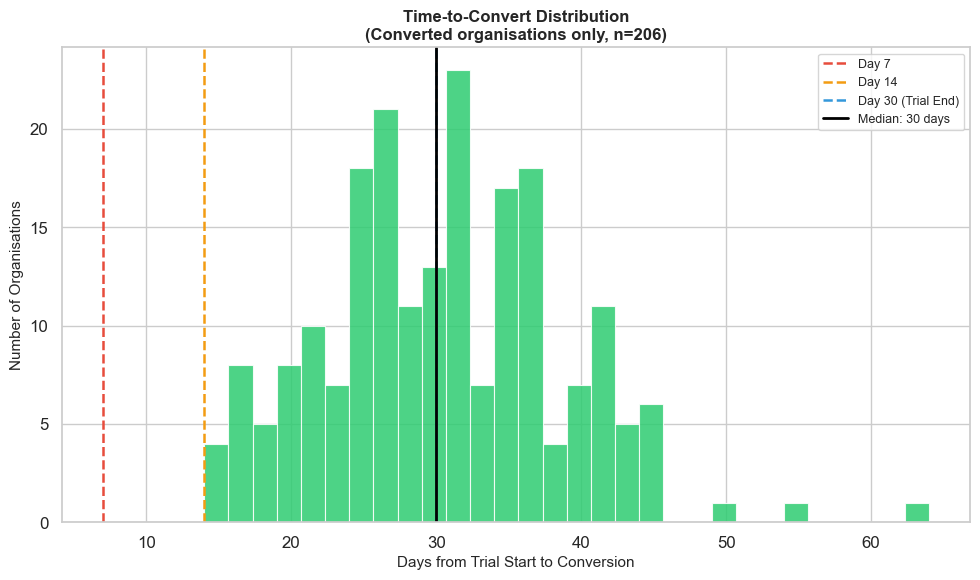

In [11]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(d2c, bins=30, color=COLORS['converted'], edgecolor='white',
        linewidth=0.8, alpha=0.85)
for day, col, lbl in [(7,  '#e74c3c', 'Day 7'),
                      (14, '#f39c12', 'Day 14'),
                      (30, '#3498db', 'Day 30 (Trial End)')]:
    ax.axvline(day, color=col, linestyle='--', linewidth=1.8, label=lbl)
ax.axvline(d2c.median(), color='black', linestyle='-', linewidth=2,
           label=f'Median: {d2c.median():.0f} days')
ax.set_xlabel('Days from Trial Start to Conversion', fontsize=11)
ax.set_ylabel('Number of Organisations', fontsize=11)
ax.set_title('Time-to-Convert Distribution\n(Converted organisations only, n=206)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


>**Time-to-Convert Distribution Histogram**
Shows the distribution of how many days elapsed between trial start
and conversion for all 206 organisations that converted to paid.
The vertical reference lines mark Day 7, Day 14, and the trial
deadline at Day 30, with the median conversion day overlaid in
black. The strong cluster of conversions near Day 30 reveals that
the majority of organisations wait until trial expiry before making
their conversion decision — suggesting that deadline pressure, rather
than an in-trial value moment, is the primary trigger for conversion.

## **Metric 5 — Daily Event Volume Across the Trial**

Daily event volume tracks the average number of in-app events generated
per organisation on each day of the 30-day trial, reported separately
for converted and non-converted groups. This metric reveals the engagement
curve — when organisations are most active, whether activity sustains
across the full trial window or drops off after the first few days, and
whether converted organisations show a meaningfully different daily
engagement pattern compared to those that did not convert.

In [12]:
# Daily Event Engagement (Trial-Day View)

daily = (
    df[df['trial_day_int'].between(0, 30)]
    .groupby(['CONVERTED', 'trial_day_int'])
    .size()
    .reset_index(name='event_count')
)
# Normalise by number of orgs in each group
daily['events_per_org'] = daily.apply(
    lambda r: r['event_count'] / (n_conv if r['CONVERTED'] else (n_total - n_conv)),
    axis=1
)

print("\n  Average events per org per trial day (selected days):")
print(f"  {'Day':>5}  {'Converted':>12}  {'Not Converted':>14}")
print("  " + "-" * 35)
for day in [0, 1, 3, 7, 14, 21, 28, 30]:
    c  = daily.loc[(daily['CONVERTED'] == True)  & (daily['trial_day_int'] == day), 'events_per_org']
    nc = daily.loc[(daily['CONVERTED'] == False) & (daily['trial_day_int'] == day), 'events_per_org']
    cv  = c.values[0]  if len(c) > 0  else 0
    ncv = nc.values[0] if len(nc) > 0 else 0
    print(f"  {day:>5}  {cv:>12.2f}  {ncv:>14.2f}")


  Average events per org per trial day (selected days):
    Day     Converted   Not Converted
  -----------------------------------
      0         18.26           16.16
      1          5.56            3.79
      3          1.40            2.34
      7          2.50            2.32
     14          3.00            3.07
     21          5.05            2.98
     28          3.41            3.62
     30          0.00            0.00


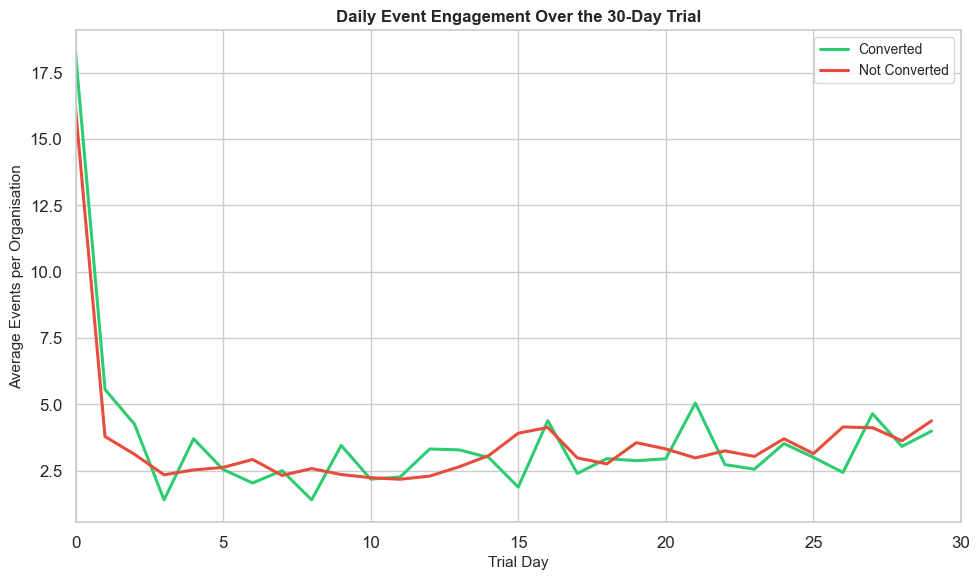

In [13]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
for conv_flag, label, color in [
    (True,  'Converted',     COLORS['converted']),
    (False, 'Not Converted', COLORS['not_converted'])
]:
    subset = daily[daily['CONVERTED'] == conv_flag].sort_values('trial_day_int')
    ax.plot(subset['trial_day_int'], subset['events_per_org'],
            color=color, label=label, linewidth=2.2)
ax.set_xlabel('Trial Day', fontsize=11)
ax.set_ylabel('Average Events per Organisation', fontsize=11)
ax.set_title('Daily Event Engagement Over the 30-Day Trial',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, 30)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


>**Daily Event Engagement Over the 30-Day Trial Line chart**
Tracks the average number of in-app events generated per organisation
on each day of the trial, plotted separately for converted and
non-converted groups. This chart reveals the engagement curve —
when organisations are most active (predominantly Day 0), how
quickly activity drops off after the initial onboarding period,
and whether converted organisations sustain meaningfully different
engagement levels compared to those that do not convert across
the full 30-day window.

## **Metric 6 — Goal Drop-off Funnel**

The goal drop-off funnel applies sequential logic to the 5 trial goals —
an organisation must pass each goal in order before it can reach the next.
Starting from all 966 organisations, we track how many pass Goal 1, then
how many of those also pass Goal 2, and so on through to full activation.
The percentage of organisations that drop off at each transition reveals
exactly where in the product journey the biggest friction points exist,
giving the product team a clear prioritisation of where onboarding
improvements would have the greatest impact.

In [14]:
# Goal Drop-Off Funnel

# Ordered, sequential funnel (must pass each stage to reach the next)
funnel_stages = [
    ('Signed up for trial',                 n_total),
    ('G1 — Core Scheduling (≥3 shifts)',    org_df['goal_1_core_scheduling'].sum()),
    ('G2 — Schedule Viewed (≥3 times)',
        (org_df['goal_1_core_scheduling'] &
         org_df['goal_2_schedule_visibility']).sum()),
    ('G3 — Time Tracking (≥1 punch-in)',
        org_df[['goal_1_core_scheduling',
                'goal_2_schedule_visibility',
                'goal_3_time_tracking']].all(axis=1).sum()),
    ('G4 — Payroll Approval (≥1 approval)',
        org_df[['goal_1_core_scheduling',
                'goal_2_schedule_visibility',
                'goal_3_time_tracking',
                'goal_4_payroll_approval']].all(axis=1).sum()),
    ('G5 — Team Comms (≥1 message)  [ACTIVATED]',
        org_df['trial_activated'].sum()),
]

print(f"\n  {'Stage':<48} {'N':>5}  {'% of Start':>11}  {'Drop-off':>9}")
print("  " + "-" * 78)
prev = n_total
for stage, count in funnel_stages:
    drop = prev - count
    drop_pct = drop / prev * 100 if prev > 0 else 0
    pct_start = count / n_total * 100
    print(f"  {stage:<48} {count:>5}  {pct_start:>10.1f}%  {drop_pct:>8.1f}%")
    prev = count


  Stage                                                N   % of Start   Drop-off
  ------------------------------------------------------------------------------
  Signed up for trial                                966       100.0%       0.0%
  G1 — Core Scheduling (≥3 shifts)                   563        58.3%      41.7%
  G2 — Schedule Viewed (≥3 times)                    256        26.5%      54.5%
  G3 — Time Tracking (≥1 punch-in)                   165        17.1%      35.5%
  G4 — Payroll Approval (≥1 approval)                101        10.5%      38.8%
  G5 — Team Comms (≥1 message)  [ACTIVATED]           65         6.7%      35.6%


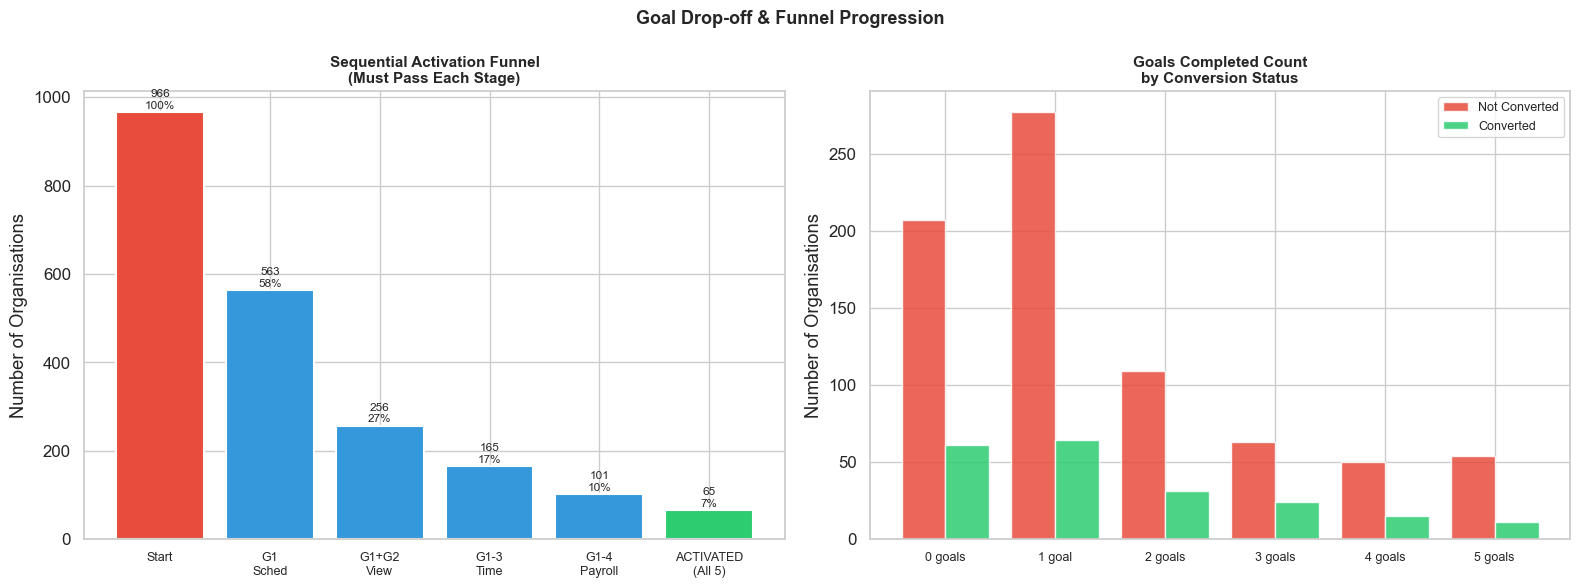

In [15]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Goal Drop-off & Funnel Progression', fontweight='bold', fontsize=13)

# Sequential funnel
ax = axes[0]
funnel_labels_short = ['Start', 'G1\nSched', 'G1+G2\nView',
                       'G1-3\nTime', 'G1-4\nPayroll', 'ACTIVATED\n(All 5)']
funnel_counts = [f[1] for f in funnel_stages]
bar_cols_f = ([COLORS['not_converted']] +
              [COLORS['neutral']] * 4 +
              [COLORS['converted']])
bars = ax.bar(range(6), funnel_counts, color=bar_cols_f,
              edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, funnel_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{count}\n{count/n_total:.0%}',
            ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(range(6))
ax.set_xticklabels(funnel_labels_short, fontsize=9)
ax.set_ylabel('Number of Organisations')
ax.set_title('Sequential Activation Funnel\n(Must Pass Each Stage)',
             fontweight='bold', fontsize=11)

# Goals completed count by conversion status
ax = axes[1]
org_df['goals_completed_n'] = org_df[GOAL_COLS].sum(axis=1)
gcd_conv   = org_df[org_df['converted']].groupby('goals_completed_n').size()
gcd_noconv = org_df[~org_df['converted']].groupby('goals_completed_n').size()
idx = sorted(set(gcd_conv.index) | set(gcd_noconv.index))
gcd_conv   = gcd_conv.reindex(idx,   fill_value=0)
gcd_noconv = gcd_noconv.reindex(idx, fill_value=0)
x_g = np.arange(len(idx))
w_g = 0.4
ax.bar(x_g - w_g/2, gcd_noconv.values, w_g, label='Not Converted',
       color=COLORS['not_converted'], alpha=0.85, edgecolor='white')
ax.bar(x_g + w_g/2, gcd_conv.values,   w_g, label='Converted',
       color=COLORS['converted'],     alpha=0.85, edgecolor='white')
ax.set_xticks(x_g)
ax.set_xticklabels([f'{i} goal{"s" if i!=1 else ""}' for i in idx], fontsize=9)
ax.set_ylabel('Number of Organisations')
ax.set_title('Goals Completed Count\nby Conversion Status',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

>**Sequential Activation Funnel (Bar Chart)**
Applies strict sequential logic to the 5 trial goals — an organisation
must complete each goal before reaching the next. Starting from all
966 organisations, the bars show how many pass through each successive
stage, revealing where the largest drops occur. The steepest drop is
between Goal 1 and Goal 2 (563 → 256 orgs, a 54.5% fall-off), making
Schedule Visibility the single biggest activation bottleneck in the
entire product journey.

>**Goals Completed Count by Conversion Status (Grouped Bar)**
Shows how many goals each organisation completed (0 through 5),
broken down by whether they converted or not. This chart tests
whether completing more goals is associated with higher conversion —
and reveals that conversion rates remain broadly stable regardless
of how many goals were completed, reinforcing the finding that
conversion is driven by intent rather than in-trial behaviour.

## **Metric 7 — Feature Engagement Depth**

While adoption rates tell us whether an organisation ever used a feature,
engagement depth tells us how intensively they used it. For each activity,
we compute the median, mean, and 90th percentile event count among
organisations that used it at least once. High-depth features are deeply
embedded in those organisations' workflows; low-depth features may be
tried once and abandoned. This distinction helps separate features that
are genuinely valuable to users from those that attract one-time
exploration without driving continued engagement.


In [16]:
# Feature Engagement Depth 

depth_rows = []
for act in ACTIVITY_COLS:
    users = org_df[org_df[act] > 0]
    if len(users) < 5:
        continue
    depth_rows.append({
        'activity':       act,
        'n_orgs_using':   len(users),
        'median_events':  users[act].median(),
        'mean_events':    users[act].mean(),
        'p90_events':     users[act].quantile(0.9),
    })
depth_df = pd.DataFrame(depth_rows).sort_values('median_events', ascending=False)

print(f"\n  {'Activity':<45} {'N':>5}  {'Median':>8}  {'Mean':>8}  {'P90':>8}")
print("  " + "-" * 78)
for _, row in depth_df.iterrows():
    print(f"  {row['activity']:<45} {row['n_orgs_using']:>5.0f}  "
          f"{row['median_events']:>8.1f}  {row['mean_events']:>8.1f}  {row['p90_events']:>8.1f}")



  Activity                                          N    Median      Mean       P90
  ------------------------------------------------------------------------------
  ShiftDetails.View.Opened                         45      16.0      31.8      55.6
  Break.Activate.Started                            6      11.5      26.8      68.0
  Break.Activate.Finished                           6      10.5      26.5      68.0
  Mobile.Schedule.Loaded                          456      10.0     108.6     309.0
  PunchClock.PunchedOut                             8       7.5      15.4      30.3
  Scheduling.Shift.Created                        848       5.5      37.5     115.5
  Integration.Xero.PayrollExport.Synced             6       5.0       5.2       9.0
  PunchClock.PunchedIn                            211       4.0      22.9      69.0
  Communication.Message.Created                   145       4.0      10.9      24.0
  Scheduling.Shift.AssignmentChanged              343       4.0      22.2     

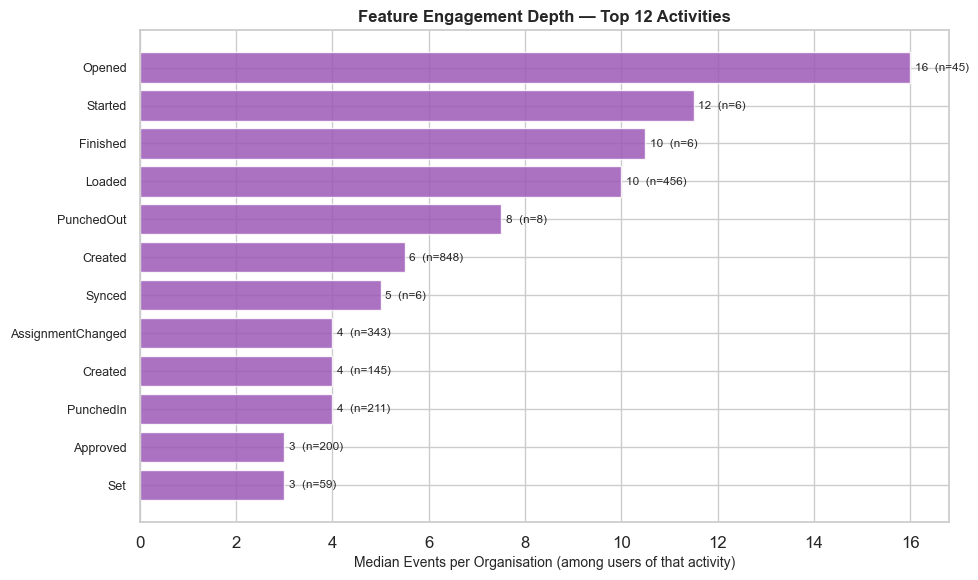

In [17]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_depth = depth_df.head(12).sort_values('median_events')
ax.barh(range(len(top_depth)), top_depth['median_events'],
        color=COLORS['purple'], alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(top_depth.iterrows()):
    ax.text(row['median_events'] + 0.1, i,
            f"{row['median_events']:.0f}  (n={row['n_orgs_using']})",
            va='center', fontsize=8.5)
ax.set_yticks(range(len(top_depth)))
ax.set_yticklabels([a.split('.')[-1][:32] for a in top_depth['activity']],
                   fontsize=9)
ax.set_xlabel('Median Events per Organisation (among users of that activity)',
              fontsize=10)
ax.set_title('Feature Engagement Depth — Top 12 Activities',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

>**Feature Engagement Depth bar graph**
Shows the median number of times each activity was performed among
organisations that used it at least once, for the top 12 activities.
This separates features that attract deep, repeated usage from those
that are tried once and abandoned. For example, Mobile.Schedule.Loaded
has a median of 10 events among its users — indicating it becomes
a habitual daily behaviour — whereas activities like Templates Applied
have a median of 3, suggesting one-time configuration rather than
ongoing use. This informs which features are genuinely embedded in
user workflows versus which need better in-app guidance to drive
continued engagement.

## **Metric 8 — Weekly Retention Proxy**

The weekly retention proxy measures what percentage of organisations
were still generating in-app events in each successive week of the
30-day trial — Week 1 (Days 0–6), Week 2 (Days 7–13), Week 3
(Days 14–20), and Week 4 (Days 21–27). Reported separately for
converted and non-converted groups, this metric acts as a proxy for
sustained engagement — showing whether organisations remain active
throughout the trial or go quiet after the initial onboarding period,
and whether converted organisations sustain engagement differently
from those that ultimately did not convert.

In [18]:
# Metric 8: Retention Proxy (Trial-Day Activity Survival)

# "Active at week N" = org had at least 1 event in that week
for conv_flag in [True, False]:
    subset = df[df['CONVERTED'] == conv_flag]
    n_grp  = subset['ORGANIZATION_ID'].nunique()
    label  = 'Converted' if conv_flag else 'Not Converted'
    print(f"\n  {label} (n={n_grp}):")
    for week_start in [0, 7, 14, 21]:
        week_end = week_start + 7
        active = subset[
            subset['trial_day_int'].between(week_start, week_end - 1)
        ]['ORGANIZATION_ID'].nunique()
        print(f"    Week {week_start//7 + 1} (days {week_start}–{week_end-1}): "
              f"{active}/{n_grp} orgs active ({active/n_grp:.1%})")


  Converted (n=206):
    Week 1 (days 0–6): 198/206 orgs active (96.1%)
    Week 2 (days 7–13): 43/206 orgs active (20.9%)
    Week 3 (days 14–20): 39/206 orgs active (18.9%)
    Week 4 (days 21–27): 44/206 orgs active (21.4%)

  Not Converted (n=760):
    Week 1 (days 0–6): 726/760 orgs active (95.5%)
    Week 2 (days 7–13): 163/760 orgs active (21.4%)
    Week 3 (days 14–20): 138/760 orgs active (18.2%)
    Week 4 (days 21–27): 134/760 orgs active (17.6%)


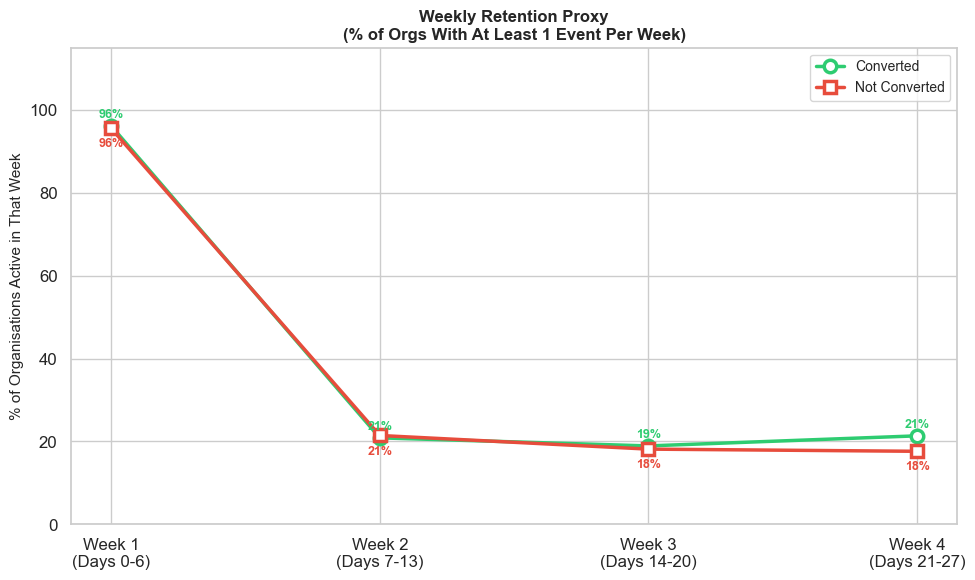

In [19]:
# Visualization
weeks       = ['Week 1\n(Days 0-6)', 'Week 2\n(Days 7-13)',
               'Week 3\n(Days 14-20)', 'Week 4\n(Days 21-27)']
week_bounds = [(0, 6), (7, 13), (14, 20), (21, 27)]
retention   = {True: [], False: []}
for conv_flag in [True, False]:
    subset = df[df['CONVERTED'] == conv_flag]
    n_grp  = subset['ORGANIZATION_ID'].nunique()
    for ws, we in week_bounds:
        active = subset[
            subset['trial_day_int'].between(ws, we)
        ]['ORGANIZATION_ID'].nunique()
        retention[conv_flag].append(active / n_grp * 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(weeks, retention[True],  'o-', color=COLORS['converted'],
        linewidth=2.5, markersize=9, label='Converted',
        markerfacecolor='white', markeredgewidth=2.5)
ax.plot(weeks, retention[False], 's-', color=COLORS['not_converted'],
        linewidth=2.5, markersize=9, label='Not Converted',
        markerfacecolor='white', markeredgewidth=2.5)
for i, (yc, yn) in enumerate(zip(retention[True], retention[False])):
    ax.text(i, yc + 2,   f'{yc:.0f}%', ha='center', fontsize=9,
            color=COLORS['converted'],     fontweight='bold')
    ax.text(i, yn - 4.5, f'{yn:.0f}%', ha='center', fontsize=9,
            color=COLORS['not_converted'], fontweight='bold')
ax.set_ylabel('% of Organisations Active in That Week', fontsize=11)
ax.set_title('Weekly Retention Proxy\n(% of Orgs With At Least 1 Event Per Week)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()


>**Weekly Retention Proxy** chart
Tracks the percentage of organisations that generated at least one
in-app event in each successive week of the 30-day trial, reported
separately for converted and non-converted groups. The sharp drop
from Week 1 (≈96%) to Week 2 (≈21%) for both groups reveals that
the vast majority of trial engagement is concentrated in the first
week — and that converted and

## **Metric 9 — Activation Bottleneck Analysis**

The bottleneck analysis identifies the single most common point of
failure in the activation funnel — the first trial goal that each
organisation failed to complete. Unlike the sequential funnel in
Metric 6, this analysis assigns every non-activated organisation to
exactly one bottleneck category based on where it stalled. The result
is a ranked breakdown of the most common reasons organisations fail
to activate, telling the product team precisely which goal to prioritise
in onboarding improvements to unlock the greatest increase in the
activation rate.

In [20]:
# First Bottleneck Analysis

def first_incomplete(row):
    for g in GOAL_COLS:
        if not row[g]:
            return g.replace('goal_', '').replace('_', ' ').title()
    return 'Fully Activated'

org_df['first_bottleneck'] = org_df.apply(first_incomplete, axis=1)
bottleneck_counts = org_df['first_bottleneck'].value_counts()
print()
for stage, count in bottleneck_counts.items():
    pct = count / n_total * 100
    bar = '█' * int(pct / 2)
    print(f"  {stage:<35} {count:>5}  ({pct:4.1f}%)  {bar}")


  1 Core Scheduling                     403  (41.7%)  ████████████████████
  2 Schedule Visibility                 307  (31.8%)  ███████████████
  3 Time Tracking                        91  ( 9.4%)  ████
  Fully Activated                        65  ( 6.7%)  ███
  4 Payroll Approval                     64  ( 6.6%)  ███
  5 Team Comms                           36  ( 3.7%)  █


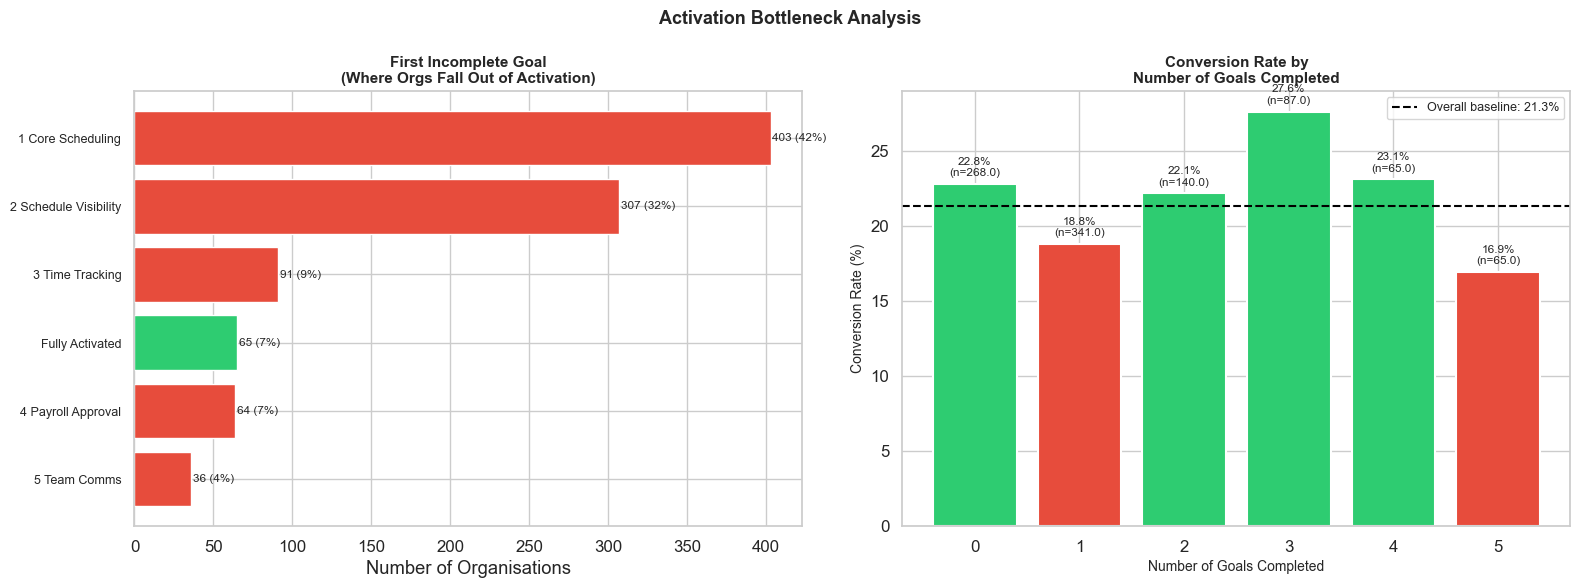

In [21]:
# Visualization

# Compute first_bottleneck column
def first_incomplete(row):
    for g in GOAL_COLS:
        if not row[g]:
            return g.replace('goal_', '').replace('_', ' ').title()
    return 'Fully Activated'

org_df['first_bottleneck'] = org_df.apply(first_incomplete, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Activation Bottleneck Analysis', fontweight='bold', fontsize=13)

# Left: First incomplete goal
ax = axes[0]
btl = org_df['first_bottleneck'].value_counts().sort_values()
bar_c = [COLORS['converted'] if 'Fully' in s
         else COLORS['not_converted'] for s in btl.index]
bars = ax.barh(range(len(btl)), btl.values, color=bar_c,
               edgecolor='white', linewidth=1)
ax.set_yticks(range(len(btl)))
ax.set_yticklabels([s[:40] for s in btl.index], fontsize=9)
for bar, v in zip(bars, btl.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{v} ({v/n_total:.0%})', va='center', fontsize=8.5)
ax.set_xlabel('Number of Organisations')
ax.set_title('First Incomplete Goal\n(Where Orgs Fall Out of Activation)',
             fontweight='bold', fontsize=11)

# Right: Conversion rate by goals completed count
ax = axes[1]
conv_by_goals = org_df.groupby('goals_completed_n').agg(
    n    = ('ORGANIZATION_ID', 'count'),
    conv = ('converted',       'mean')
).reset_index()
bar_cols_g = [COLORS['not_converted'] if v < conv_rate
              else COLORS['converted'] for v in conv_by_goals['conv']]
bars = ax.bar(conv_by_goals['goals_completed_n'], conv_by_goals['conv'] * 100,
              color=bar_cols_g, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, conv_by_goals.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{row['conv']:.1%}\n(n={row['n']})",
            ha='center', va='bottom', fontsize=8.5)
ax.axhline(conv_rate * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall baseline: {conv_rate:.1%}')
ax.set_xlabel('Number of Goals Completed', fontsize=10)
ax.set_ylabel('Conversion Rate (%)', fontsize=10)
ax.set_title('Conversion Rate by\nNumber of Goals Completed',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

>**First Incomplete Goal (Horizontal Bar)**
Every organisation is assigned to the first goal it failed to complete,
evaluated in product-logic order: Scheduling → Visibility → Time
Tracking → Payroll → Communications. The chart ranks these bottleneck
categories from most to least common, showing both the raw count and
the percentage of all 966 organisations that stalled at each point.
Organisations that completed all 5 goals are shown separately as
"Fully Activated" in green, providing a visual reference for the
scale of the gap between the largest bottleneck and full activation.

>**Conversion Rate by Number of Goals Completed (Bar)**
For each possible goals-completed count (0 through 5), this chart
shows the conversion rate of organisations at that level alongside
the overall 21.3% baseline. Bars above the baseline are shown in
green; bars below in red. This reveals whether completing more goals
is associated with a meaningfully higher likelihood of converting —
or whether, consistent with our earlier finding, conversion remains
stable regardless of how many goals an org completes. Together with
Chart 10, this gives the product team both the where (which goal
blocks activation) and the so-what (does clearing that block actually
move the conversion needle).

## **Key Findings: Descriptive Analytics & Product Metrics**

**1. Conversion Rate Is Stable at 21.3%**

>The overall trial conversion rate is 21.3% — meaning roughly 1 in 5
trialling organisations becomes a paying customer. This rate is
remarkably consistent across all three monthly cohorts (January: 23.0%,
February: 22.8%, March: 18.2%), suggesting conversion performance is
not improving meaningfully over time and is largely independent of
when an organisation started their trial.

**2. Behavioural Signals Do Not Predict Conversion**

>No single in-trial activity is statistically linked to conversion.
All 28 activities return p-values above 0.05, and the Random Forest
model achieves a cross-validation AUC of approximately 0.50 — no
better than random guessing. Conversion appears to be driven by
pre-existing organisational intent rather than what organisations
do inside the product during the trial.

**3. Trial Activation Rate Is Only 6.7%**

>Only 65 of 966 organisations completed all 5 trial goals, giving a
trial activation rate of 6.7%. Notably, activated organisations
convert at a lower rate (16.9%) than non-activated organisations
(21.6%), which further confirms that activation as currently defined
is a product engagement milestone, not a conversion predictor —
and that the goals require validation through A/B testing before
being used as operational KPIs.

**4. Scheduling Is the Universal Entry Point**

>The scheduling module dominates adoption at 88% —
Scheduling.Shift.Created is by far the most used activity across
all trialling organisations. It is the natural entry point into the
platform and the activity the Random Forest model ranks as most
informative (importance: 0.307). Every other module is used by
fewer than half of organisations.

**5. Time Tracking Has the Biggest Adoption Gap**

>Only 21.8% of organisations ever use the punch clock — meaning
78.2% of trialists never activate live time tracking at all.
This is the single largest drop-off point in the activation funnel,
representing a critical failure in onboarding that prevents
organisations from experiencing the platform's core time and
attendance value.

**6. Team Communications Is the Least Discovered Feature**

>Only 15.0% of organisations send a team message during their trial —
making Communications the least adopted module on the platform.
It is also the last and hardest activation goal to reach, suggesting
either a discoverability problem (the feature is not being found)
or a value problem (organisations do not see the need during a trial).

**7. Most Conversions Happen at the Trial Deadline**

>The median time-to-convert is 30 days — exactly at the trial
expiry date. Only 1.5% of converting organisations make the
decision within 14 days, and just 51% convert within the 30-day
window. This clustering at the deadline indicates organisations
are not experiencing an early "aha moment" that drives an urgent
conversion decision — they are simply waiting until they are
forced to decide.

**8. Engagement Drops Steeply After Week 1**

>The weekly retention proxy shows that approximately 96% of
organisations are active in Week 1 of the trial. By Week 2
this drops to roughly 21% for both converted and non-converted
groups — and remains flat through Weeks 3 and 4. This steep
drop-off after the first week indicates that most organisations
complete their initial onboarding and then go quiet, with no
sustained engagement signal distinguishing those who will
eventually convert from those who will not.

**9. The Activation Funnel Has Two Critical Bottlenecks**

>Applying sequential funnel logic to the 5 goals reveals two
major drop-off points. The first is at Goal 1 — 41.7% of
organisations never even create 3 shifts. The second and largest
is the transition from Goal 1 to Goal 2, where 54.5% of
organisations that complete scheduling never go on to view their
schedule 3 or more times. Together these two steps account for
the majority of activation failures and represent the highest-
priority targets for onboarding improvement.

## **Business Recommendations for the Product Team**

**1. Conversion Is Intent-Driven, Not Behaviour-Driven**

>No single in-trial behaviour is statistically linked to conversion
(all p > 0.05, CV AUC ≈ 0.50). Conversion likely reflects
pre-existing organisational intent. Invest in pre-trial sales
qualification and discovery calls rather than in-trial nudges alone.

**2. Scheduling Is Universal — Build the Onboarding Around It**

>88% of organisations create shifts (Goal 1). This is the natural
entry point. Onboarding should immediately guide admins through
creating their first real-work shift — not a demo — to anchor
engagement in the platform's core workflow from day one.

**3. Time Tracking Has a Massive Adoption Gap**

>Only 22% of organisations ever punch in. This is the single biggest
drop-off in the activation funnel. Recommended action: introduce a
Day 3–5 in-app prompt asking the admin to invite an employee to
clock in on mobile — bridging the gap between scheduling and live
time tracking.

**4. Team Comms Is the Hardest Goal to Reach**

>Only 15% of organisations send a team message. Consider whether
this is a discoverability issue (feature hidden) or a value issue
(not compelling enough during a trial). Run an A/B test: surface
team communications in the onboarding checklist vs a control group
to measure whether visibility alone drives adoption.

**5. Conversions Cluster at Day 30 — Create Urgency Earlier**

>Median time-to-convert is 30 days — the trial deadline. Most
organisations wait until the last possible moment to decide.
Introduce a Day 20 email — *"Your trial ends in 10 days — here's
your usage summary"* — to surface the value already delivered and
prompt earlier, less pressured conversion decisions.

**6. Trial Activation Rate Is Only 6.7% — Reduce Onboarding Friction**

>Only 65 of 966 organisations complete all 5 goals. An interactive
onboarding checklist that guides organisations step-by-step through
each goal — with visible progress tracking — could significantly
increase this rate and give the product team a clear, measurable
in-trial health signal to monitor over time.

**7. Weekly Retention Drops Steeply After Week 1**

>Activity tails off sharply after Week 1 for both converted and
non-converted organisations. A weekly digest email — *"Here's your
team's activity this week"* — could re-engage dormant trialists,
extend the active engagement window, and keep the platform top of
mind through to the conversion decision point.